# ClimateGuard AI v3.0 - Climate Risk Score

This notebook covers calculating comprehensive climate risk scores based on weather parameters. 

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))

from src.models.climate_risk_score import ClimateRiskScorer

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Climate Zones Data

In [2]:
# Load data from climate profiling step
df = pd.read_csv('../data/processed/09_heatwave_predictions.csv')
expected_rows = len(df)

# Normalize dataset columns to the names expected by ClimateRiskScorer
df['temperature'] = df['temperature_celsius']
df['precipitation'] = df['precip_mm']
df['pm2_5'] = df['air_quality_PM2.5']
df['wind_speed'] = df['wind_kph'] / 3.6
df['pressure'] = df['pressure_mb']

print(f"Data loaded: {df.shape}")
print(f"Input records: {expected_rows}")
print(f"Columns: {len(df.columns)}")

Data loaded: (119398, 91)
Input records: 119398
Columns: 91


## 3. Initialize Climate Risk Scorer

In [3]:
import pickle
import os

# Initialize and save the Climate Risk Scorer
scorer = ClimateRiskScorer()
model_dir = '../trained_models'
os.makedirs(model_dir, exist_ok=True)

with open(f'{model_dir}/04_climate_risk_scorer.pkl', 'wb') as f:
    pickle.dump(scorer, f)

print(f"Climate Risk Scorer saved to {model_dir}/04_climate_risk_scorer.pkl")

Climate Risk Scorer saved to ../trained_models/04_climate_risk_scorer.pkl


In [4]:
scorer = ClimateRiskScorer()
print("Climate risk scorer initialized")

Climate risk scorer initialized


## 4. Calculate Risk Scores for Sample Data

In [5]:
# Test with a sample row
sample = df.iloc[0]

risk = scorer.calculate_overall_risk(
    temperature=sample.get('temperature'),
    humidity=sample.get('humidity'),
    rainfall=sample.get('precipitation'),
    pm25=sample.get('pm2_5'),
    uv_index=sample.get('uv_index'),
    wind_speed=sample.get('wind_speed'),
    pressure=sample.get('pressure')
)

print("Sample Risk Score:")
print(f"Overall Score: {risk['overall_score']}/100")
print(f"Category: {risk['category']}")
print(f"Color: {risk['color']}")
print("\nComponent Scores:")
for comp, score in risk['component_scores'].items():
    print(f"  {comp}: {score:.2f}")

INFO:src.models.climate_risk_score:Climate risk calculated: 12.04 (Low)


Sample Risk Score:
Overall Score: 12.04/100
Category: Low
Color: green

Component Scores:
  temperature: 0.00
  humidity: 17.50
  rainfall: 0.00
  air_quality: 43.40
  uv_index: 3.33
  wind_speed: 4.00
  pressure: 0.00


## 5. Calculate Risk Scores for All Data

In [6]:
print("Calculating risk scores for entire dataset...")
df = scorer.calculate_batch_risk(df)

risk_columns = ['overall_score', 'category', 'color']
missing_risk_values = df[risk_columns].isna().sum()
if missing_risk_values.any():
    raise ValueError(f"Risk scoring produced empty values: {missing_risk_values.to_dict()}")
if len(df) != expected_rows:
    raise ValueError(f"Expected {expected_rows} scored records, found {len(df)}")

print(f"Risk scores calculated for {len(df)} records")
print(f"Non-empty risk values: {df[risk_columns].notna().sum().to_dict()}")

Calculating risk scores for entire dataset...


INFO:src.models.climate_risk_score:Batch risk scores calculated for 119398 records


Risk scores calculated for 119398 records
Non-empty risk values: {'overall_score': 119398, 'category': 119398, 'color': 119398}


## 6. Analyze Risk Score Distribution

In [7]:
print("Risk Score Statistics:")
print(df['overall_score'].describe())

print("\nRisk Category Distribution:")
print(df['category'].value_counts())

Risk Score Statistics:
count    119398.000000
mean         17.012231
std           6.612684
min           0.530000
25%          13.030000
50%          16.990000
75%          20.730000
max          42.040000
Name: overall_score, dtype: float64

Risk Category Distribution:
category
Low         105416
Moderate     13982
High             0
Extreme          0
Name: count, dtype: int64


## 7. Visualize Risk Score Distribution

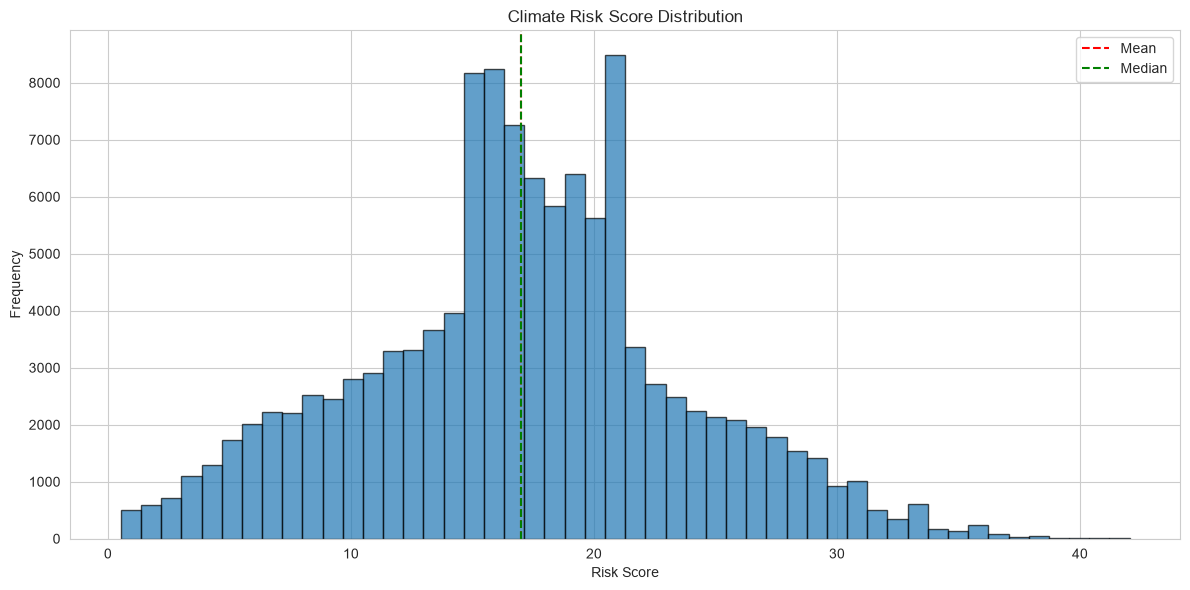

Risk score distribution plot displayed


In [8]:
plt.figure(figsize=(12, 6))
plt.hist(df['overall_score'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.title('Climate Risk Score Distribution')
plt.axvline(df['overall_score'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['overall_score'].median(), color='green', linestyle='--', label='Median')
plt.legend()
plt.tight_layout()
plt.show()
print("Risk score distribution plot displayed")

## 8. Visualize Risk Category Distribution

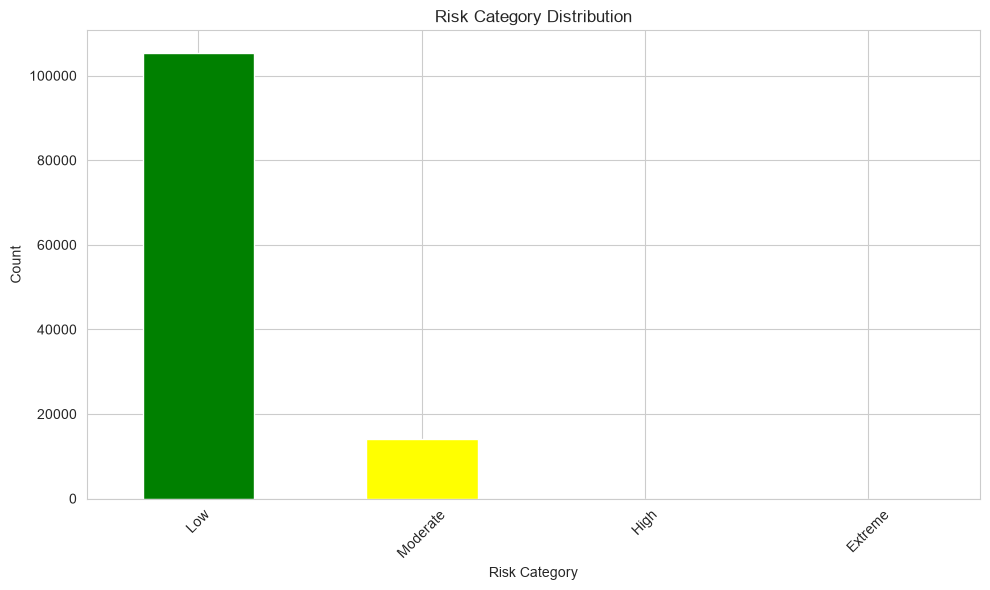

Risk category distribution plot displayed


In [9]:
plt.figure(figsize=(10, 6))
df['category'].value_counts().plot(kind='bar', color=['green', 'yellow', 'orange', 'red'])
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.title('Risk Category Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Risk category distribution plot displayed")

## 9. Risk Score by Climate Zone

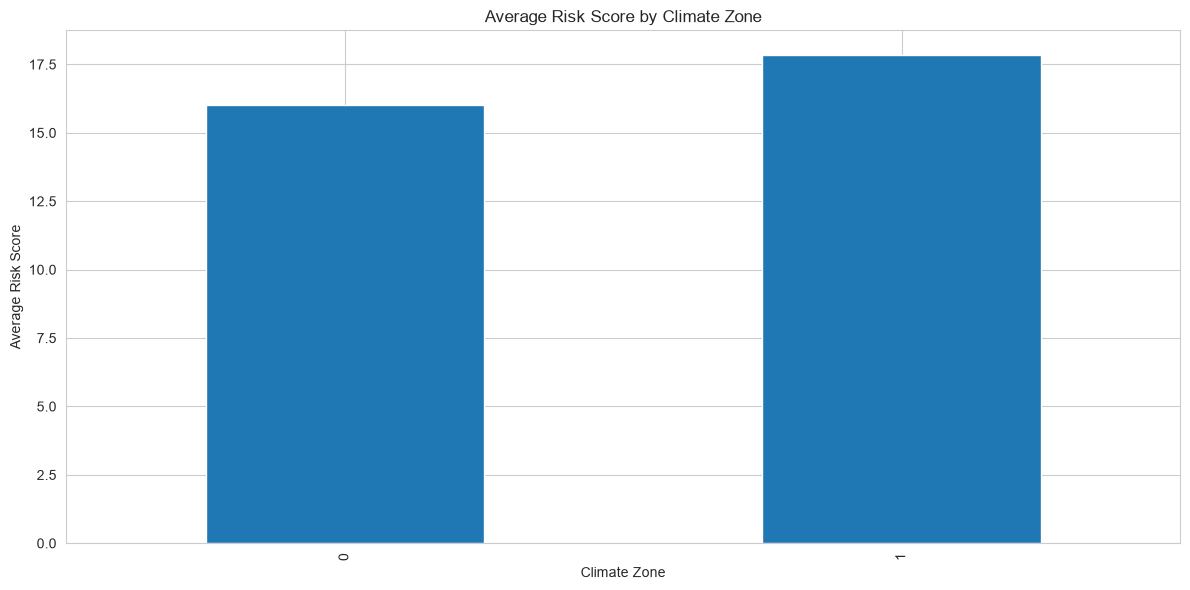

Risk by climate zone plot displayed


In [10]:
if 'climate_zone' in df.columns:
    zone_risk = df.groupby('climate_zone')['overall_score'].mean()
    
    plt.figure(figsize=(12, 6))
    zone_risk.plot(kind='bar')
    plt.xlabel('Climate Zone')
    plt.ylabel('Average Risk Score')
    plt.title('Average Risk Score by Climate Zone')
    plt.tight_layout()
    plt.show()
    print("Risk by climate zone plot displayed")

## 10. Component Risk Analysis

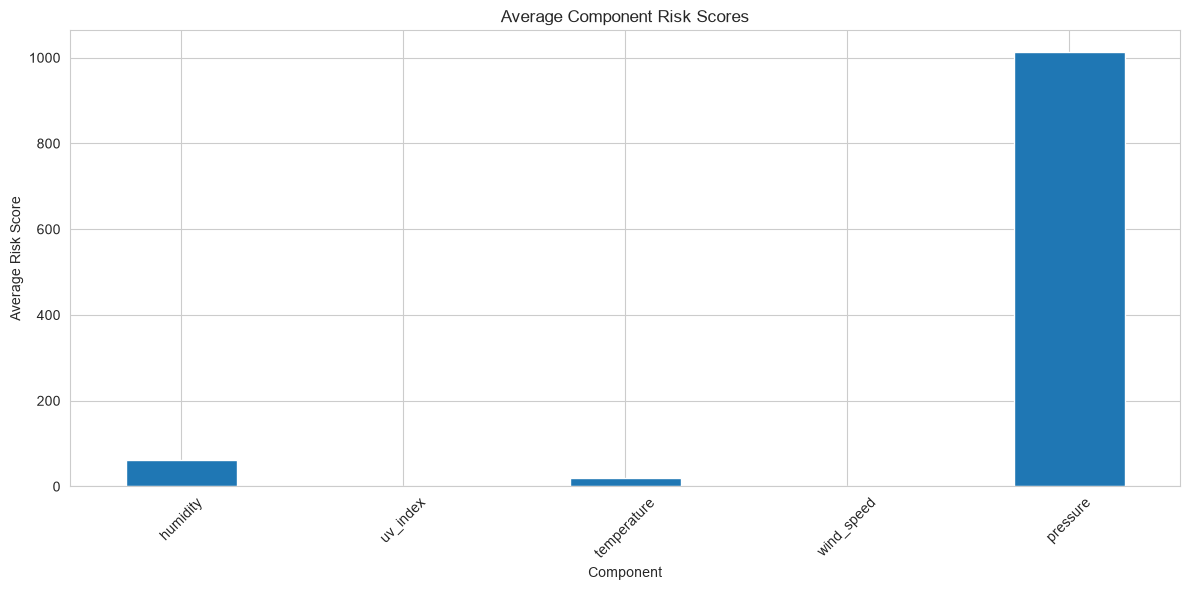

Component risk scores plot displayed


In [11]:
# Get average component scores
component_cols = [col for col in df.columns if col in scorer.risk_weights.keys()]
component_avg = df[component_cols].mean()

plt.figure(figsize=(12, 6))
component_avg.plot(kind='bar')
plt.xlabel('Component')
plt.ylabel('Average Risk Score')
plt.title('Average Component Risk Scores')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Component risk scores plot displayed")

## 11. High Risk Events Analysis

In [12]:
# Identify high risk events (score > 75)
high_risk = df[df['overall_score'] > 75]
print(f"High risk events: {len(high_risk)} ({len(high_risk)/len(df)*100:.2f}%)")

# Analyze conditions during high risk events
if len(high_risk) > 0:
    print("\nAverage conditions during high risk events:")
    for col in component_cols:
        if col in high_risk.columns:
            print(f"  {col}: {high_risk[col].mean():.2f}")

High risk events: 0 (0.00%)


## 12. Risk Score Trends Over Time

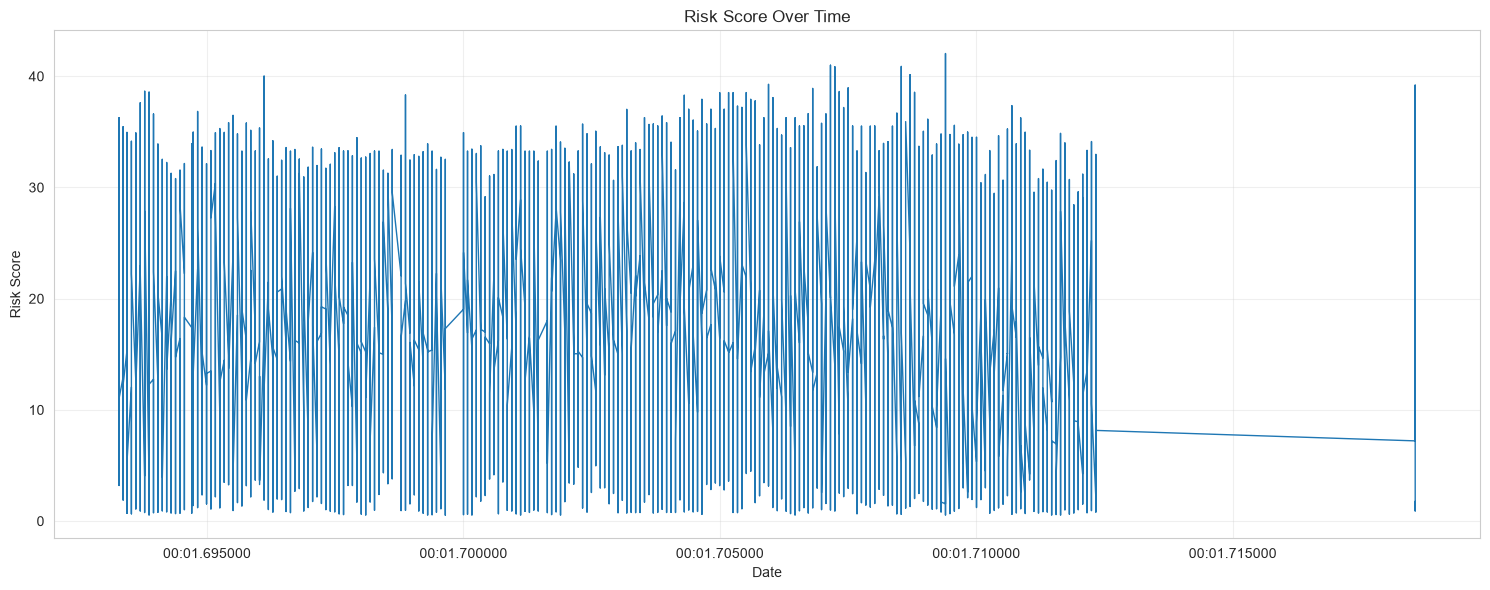

Risk score trend plot displayed


In [13]:
# Check for date column
date_cols = [col for col in df.columns if 'date' in col.lower()]
if date_cols:
    df[date_cols[0]] = pd.to_datetime(df[date_cols[0]])
    df_sorted = df.sort_values(date_cols[0])
    
    plt.figure(figsize=(15, 6))
    plt.plot(df_sorted[date_cols[0]], df_sorted['overall_score'], linewidth=1)
    plt.xlabel('Date')
    plt.ylabel('Risk Score')
    plt.title('Risk Score Over Time')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Risk score trend plot displayed")
else:
    print("No date column found for time series analysis")

## 13. Save Data with Risk Scores

In [14]:
risk_columns = ['overall_score', 'category', 'color']
if df[risk_columns].isna().any().any():
    raise ValueError("Cannot save: overall_score, category, and color must be populated for every row")
assert len(df) == expected_rows, f"Expected {expected_rows} rows before saving, found {len(df)}"

output_path = '../data/processed/10_climate_risk_scores.csv'
df.to_csv(output_path, index=False)

saved_data = pd.read_csv(output_path, usecols=risk_columns)
saved_rows = len(saved_data)
assert saved_rows == expected_rows, f"Expected {expected_rows} saved rows, found {saved_rows}"
assert saved_data.notna().all().all(), "Saved risk columns contain empty values"
print(f"Saved {saved_rows} records with complete risk scores to {output_path}")

Saved 119398 records with complete risk scores to ../data/processed/10_climate_risk_scores.csv


## Summary

In this notebook, we:
1. Loaded the climate zones data
2. Initialized the climate risk scorer
3. Calculated risk scores for sample data
4. Calculated risk scores for the entire dataset
5. Analyzed risk score distribution
6. Visualized risk score and category distributions
7. Analyzed risk by climate zone
8. Analyzed component risk scores
9. Identified high risk events
10. Analyzed risk score trends over time
11. Saved data with risk scores for anomaly detection

Next: Anomaly Detection

In [15]:
import time

start = time.time()

print("Calculating risk scores for entire dataset...")
risk_df = scorer.calculate_batch_risk(df)

end = time.time()

print(f"Risk scores calculated for {len(risk_df)} records")
print(f"Time taken: {end - start:.2f} seconds")

Calculating risk scores for entire dataset...


INFO:src.models.climate_risk_score:Batch risk scores calculated for 119398 records


Risk scores calculated for 119398 records
Time taken: 0.29 seconds
